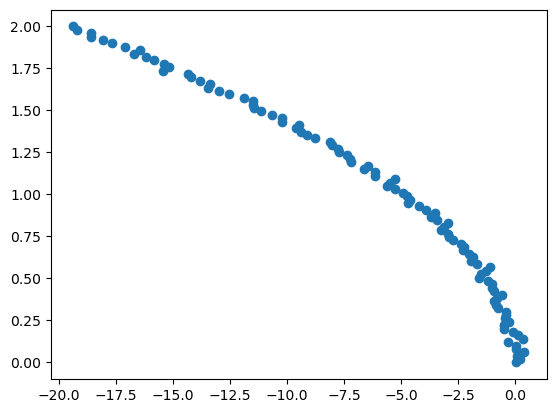

Best-fit g = 9.787878787878787
Minimum chi^2 = 103.58457183612617


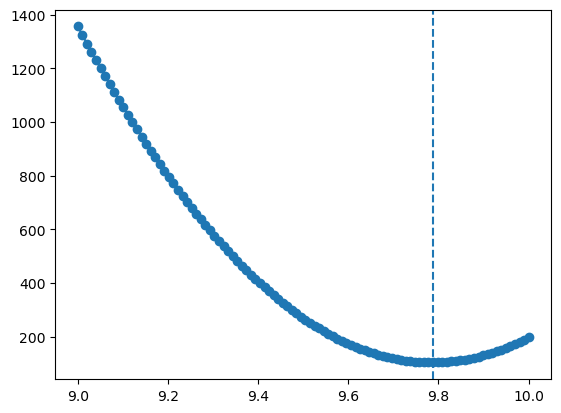

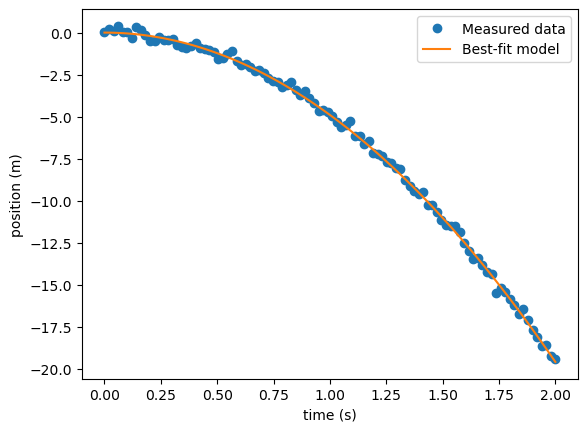

Our reduced chi square value for our best g is  1.0463088064255168


In [15]:
#An important concept in computational physics is using numerical methods to analysize real world data with theoretical models
#An example of a common practice in doing this is determining the most likely numerical value of a constant that is predidcted in a model when accounting for uncertainties
#Take for example determining the value for g, the gravitational acceleration of masses near the surface of the earth.
#There are many methods in doing this but one particular method we learned in PH264 is creating guesses for g and choosing the one that creates an acceptable and best chi square value
#A chi square value is basically how wrong your model is scaled to how much wrongness you expect giving us a numerical value to conclude if the model is resonanble or not
#Below is a simple case of applying this method 
import numpy as np
import matplotlib.pyplot as plt
# True value of g (what we're trying to recover). This seems circular since we are already using a value for g that we know but this is just for the purpose of creating a dataset. In a real world application this data would be experimentally gathered.
g_true = 9.81  # m/s^2
#Generate time data
t = np.linspace(0, 2, 100)  # 0 to 2 seconds, 20 points
#Generate ideal position data
y_true = -0.5 * g_true * t**2
#Add noise (simulate measurement error)
sigma = 0.2
noise = np.random.normal(0, sigma, size=len(t))
y_measured = y_true + noise
plt.plot(y_measured,t,marker="o",linestyle="None")
plt.show()
#Next we'll create guesses for what we think the value of g could be
gvals=np.linspace(9,10,100)
chi2=np.zeros(gvals.size)
for i in range(gvals.size): #testing each guess for g
    y_model = -0.5 * gvals[i] * t**2
    chi2[i] = np.sum((y_measured - y_model)**2 / sigma**2)
# Find best-fit g by finding the minimum chi2 value
best_index = np.argmin(chi2)
best_g = gvals[best_index]
chi2_min = chi2[best_index]

print("Best-fit g =", best_g)
print("Minimum chi^2 =", chi2_min)

# Plot chi-square vs g
plt.plot(gvals, chi2, marker="o", linestyle="-")
plt.axvline(best_g, linestyle="--", label=f"best g = {best_g:.3f}")
plt.show()

# Plot measured data with best-fit model
y_best = -0.5 * best_g * t**2
plt.plot(t, y_measured, marker="o", linestyle="None", label="Measured data")
plt.plot(t, y_best, label="Best-fit model")
plt.xlabel("time (s)")
plt.ylabel("position (m)")
plt.legend()
plt.show()
#Now we want to determine what our actual chi square value is telling us. A simple and quick way to do this is by looking at the reduced chi square value
chired=chi2_min/99
print("Our reduced chi square value for our best g is ",chired)
#A chi square value much larger than 1 indicates that the model has uncertainties far larger than expected. Either the model is wrong, uncertainties are underestimated, or the data just has extra noise or outliers.
#A chi square value smaller than 1 indicates that the model fits too "well". This means either the uncertainties are overestimated, the model is overfitting with too many parameters, or the data points are not independent and errors are correlated.
#In our case we find our reduced chi square value to be pretty close to 1, indicating that our value for g is pretty likely for the model and falls within expected noise.